# Set E Composite-Aware Sensitivity Analysis (CatBoost, V1-V3)

**Purpose:** Test whether the composite-aware, redundancy-reduced Set E predictor set
(derived from Set D by removing HSLS composite-scale redundancy, per
`HSLS_SetE_feature_audit.csv`) changes held-out performance relative to Set D. This is a
**supplementary sensitivity analysis**, not a replacement for the main modelling
pipeline -- the Set D V3 CatBoost result remains the primary reported HSLS configuration.

**Dataset:** `prepared_hsls_setE_composite_aware.csv` -- 12,829 records, 332 predictors +
`program_stream` target (Set D's 377 predictors reduced to 332 by removing documented
composite-scale redundancy; see the Set E evidence file for the Keep/Remove rationale).

**Target:** `program_stream` (`X4ENTRYMAJ4Y`, the NCES 10-category major aggregation).

**Predictors:** 332 Set E predictors.

**Experimental role:** Supplementary sensitivity analysis. Only V1-V3 are run here --
V4 (feature selection), V5 (tuning), and V6 (stacking) are intentionally not run, since
this notebook's only question is whether Set E's predictor reduction changes the V1-V3
Macro-F1 trend already established on Set D, not a search for a new best model.

**Primary metric:** Macro-F1 (test set), matching the main pipeline.

**Random state:** 42 (matches the main pipeline and the Set D CatBoost experiment).

**Output files produced:**
- `setE_composite_aware_sensitivity_all_versions_summary.csv` -- best model per version
- `setE_composite_aware_sensitivity_v1_v2_v3_per_model_results.csv` -- every model's metrics per version (used for the Set D vs Set E comparison below)
- `setE_composite_aware_sensitivity_setD_vs_setE_comparison.csv` -- CatBoost F1 by version, Set D vs Set E, built programmatically from saved results (never hard-coded)
- `fig_setD_setE_sensitivity.png`

**Dependency:** the Set D vs Set E comparison section requires
`catboost_svm_replacement_v1_v1_v2_v3_per_model_results.csv`, saved by the Set D
CatBoost supplementary experiment. That cell raises a clear error if the file is
missing rather than substituting any number.


## (Optional) Mount Google Drive
Run this if `DATA_PATH` below points to a file in Google Drive.

In [2]:
# This experiment was set up for local VS Code runs (no Colab / Drive needed).
# Left here, guarded, in case you ever run this cell in Colab instead.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Colab -- skipping Drive mount (expected for local VS Code runs).")


Mounted at /content/drive


## Install / Import

In [3]:
!pip install imbalanced-learn --quiet
!pip install catboost --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from catboost import CatBoostClassifier
# NOTE: SVC is intentionally NOT imported -- CatBoost replaces SVM here, matching
# the Set D CatBoost supplementary experiment this sensitivity analysis is compared against.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


### CONFIG -- the only section that changes per dataset/experiment

In [4]:
DATA_PATH      = "/content/drive/MyDrive/clean files/prepared_hsls_setE_composite_aware.csv"   # Set E: composite-aware, 332 predictors
TARGET_COL     = "program_stream"
COLS_TO_REMOVE = []
RANDOM_STATE   = 42

EXPERIMENT_TAG = "/content/drive/MyDrive/clean files/setE_composite_aware_sensitivity"   # all outputs from THIS file are
                                                        # prefixed with this, so they never
                                                        # collide with the Set D CatBoost run.

# Where to find the Set D CatBoost experiment's saved per-model V1-V3 results.
# This file is NOT produced by this notebook -- it must already exist from
# running the Set D CatBoost supplementary experiment (EXPERIMENT_TAG =
# "catboost_svm_replacement_v1"), which saves it with this exact filename.
SET_D_EXPERIMENT_TAG = "/content/drive/MyDrive/clean files/catboost_svm_replacement_v1"
SET_D_RESULTS_PATH = f"{SET_D_EXPERIMENT_TAG}_v1_v2_v3_per_model_results.csv"

# CatBoost defaults -- identical to the Set D CatBoost supplementary experiment, so
# CatBoost-on-Set-E is directly comparable to CatBoost-on-Set-D.
CATBOOST_DEFAULTS = dict(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3.0,
    early_stopping_rounds=30,
    val_size=0.15,      # fraction of whatever training data CatBoost receives,
                         # carved off internally for early-stopping only
    random_state=RANDOM_STATE,
    verbose=False,
)


### SHARED: load data, evaluation helpers, CatBoost wrapper, preprocessing

In [5]:
def load_data(path: str, target_col: str, cols_to_remove: list) -> pd.DataFrame:
    df = pd.read_csv(path)
    present = [c for c in cols_to_remove if c in df.columns]
    if present:
        df = df.drop(columns=present)
    if df[target_col].isnull().sum() > 0:
        before = len(df)
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        print(f"Dropped {before - len(df)} rows with missing target.")
    print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


def diagnose(f1_train, f1_test):
    gap = f1_train - f1_test
    if gap > 0.15:
        return gap, "OVERFIT"
    elif f1_test < 0.50 and f1_train < 0.50:
        return gap, "UNDERFIT"
    return gap, "GOOD FIT"


def evaluate(model, X_train, y_train, X_test, y_test, cv, name, extra=None):
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_test = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_train = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    gap, diag = diagnose(f1_train, f1_test)

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    row = {
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Test": round(f1_test, 4),
        "F1 Train": round(f1_train, 4),
        "Train-Test Gap": round(gap, 4),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "Diagnosis": diag,
    }
    if extra:
        row.update(extra)
    return row


class CatBoostEarlyStop(BaseEstimator, ClassifierMixin):
    """CatBoost wrapper with self-contained early stopping. Carves its own
    train/validation split out of whatever training data it receives at
    .fit() time, so the held-out test set never participates in early
    stopping regardless of where this is called from (plain .fit(),
    cross_val_score, or a Pipeline step)."""

    def __init__(self, iterations=500, depth=6, learning_rate=0.1,
                 l2_leaf_reg=3.0, early_stopping_rounds=30,
                 val_size=0.15, random_state=42, verbose=False):
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.l2_leaf_reg = l2_leaf_reg
        self.early_stopping_rounds = early_stopping_rounds
        self.val_size = val_size
        self.random_state = random_state
        self.verbose = verbose

    def _build_model(self):
        return CatBoostClassifier(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            l2_leaf_reg=self.l2_leaf_reg,
            random_state=self.random_state,
            verbose=self.verbose,
            loss_function="MultiClass",
        )

    def fit(self, X, y):
        y = np.asarray(y)
        min_class_count = pd.Series(y).value_counts().min()
        try:
            if min_class_count < 2:
                raise ValueError("class too small to stratify")
            X_tr, X_val, y_tr, y_val = train_test_split(
                X, y, test_size=self.val_size, random_state=self.random_state, stratify=y
            )
        except ValueError:
            X_tr, X_val, y_tr, y_val = train_test_split(
                X, y, test_size=self.val_size, random_state=self.random_state
            )

        self.model_ = self._build_model()
        self.model_.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=self.early_stopping_rounds,
            use_best_model=True,
            verbose=self.verbose,
        )
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return np.asarray(self.model_.predict(X)).ravel()

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


BASE_MODEL_DEFS = lambda: {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "CatBoost": CatBoostEarlyStop(**CATBOOST_DEFAULTS),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}


def smote_k_for(y_train):
    min_class_count = pd.Series(y_train).value_counts().min()
    return max(1, min(5, min_class_count - 1))


def make_cv(y):
    """StratifiedKFold with n_splits capped by the smallest class's size."""
    min_class_count = pd.Series(y).value_counts().min()
    n_splits = min(5, int(min_class_count))
    if n_splits < 2:
        raise ValueError(
            f"Cross-validation impossible: smallest class has only "
            f"{min_class_count} sample(s), need at least 2 for any CV split."
        )
    if n_splits < 5:
        print(f"  NOTE: smallest class has {min_class_count} samples -- "
              f"using {n_splits}-fold CV instead of the default 5-fold.")
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def determine_column_types(df_train_raw: pd.DataFrame, target_col: str):
    """Classifies each predictor as continuous / discrete / categorical from the
    training schema -- a structural decision, done once, not fold-sensitive."""
    numeric_cols = df_train_raw.select_dtypes(include="number").columns.tolist()
    categorical_cols = [c for c in df_train_raw.select_dtypes(include="object").columns if c != target_col]
    continuous_cols, discrete_cols = [], []
    for col in numeric_cols:
        if col == target_col:
            continue
        non_null = df_train_raw[col].dropna()
        is_integer = non_null.apply(lambda x: x == int(x)).all() if len(non_null) else True
        n_unique = df_train_raw[col].nunique()
        if is_integer and n_unique <= 20:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)
    return continuous_cols, discrete_cols, categorical_cols


def build_preprocessor(continuous_cols, discrete_cols, categorical_cols):
    """Unfitted ColumnTransformer: mean-impute continuous, median-impute discrete,
    mode-impute + ordinal-encode categorical. Fitting happens fresh every time this
    is cloned into a Pipeline and that Pipeline is fit, which is what keeps
    imputation/encoding statistics fold-safe."""
    continuous_pipe = SkPipeline([("impute", SimpleImputer(strategy="mean"))])
    discrete_pipe = SkPipeline([("impute", SimpleImputer(strategy="median"))])
    categorical_pipe = SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer(transformers=[
        ("cont", continuous_pipe, continuous_cols),
        ("disc", discrete_pipe, discrete_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])


### V1 -- Raw baseline: dropna, label-encode, no scaling, no SMOTE

In [6]:
def run_v1(df: pd.DataFrame):
    print("\n" + "=" * 70)
    print("V1 -- Raw baseline (dropna, label-encode, no scaling, no SMOTE)")
    print("=" * 70)

    df_v1 = df.dropna().copy()
    print(f"Records after dropna: {len(df_v1)} (from {len(df)})")

    X_raw = df_v1.drop(columns=[TARGET_COL])
    y_raw = df_v1[TARGET_COL]

    X_train_raw, X_test_raw, y_train_labels, y_test_labels = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_raw
    )

    label_encoders = {}
    X_train = X_train_raw.copy()
    X_test = X_test_raw.copy()
    cat_cols = X_train_raw.select_dtypes(include="object").columns.tolist()

    for col in cat_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train_raw[col].astype(str))
        known = set(le.classes_)
        test_vals = X_test_raw[col].astype(str)
        unseen = ~test_vals.isin(known)
        encoded_test = np.full(len(test_vals), -1, dtype=int)
        encoded_test[~unseen] = le.transform(test_vals[~unseen])
        X_test[col] = encoded_test
        label_encoders[col] = le

    le_target = LabelEncoder()
    le_target.fit(y_train_labels)
    y_train = le_target.transform(y_train_labels)
    y_test = le_target.transform(y_test_labels)

    cv = make_cv(y_train)
    results = []
    for name, model in BASE_MODEL_DEFS().items():
        model.fit(X_train, y_train)
        row = evaluate(model, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results)


### SHARED: V2-V3 preprocessing (split before impute, then scale)

In [7]:
def prepare_v2_style(df: pd.DataFrame):
    """Split BEFORE any preprocessing. Only column TYPES (continuous/discrete/
    categorical) are determined here -- a structural decision, not a
    fold-sensitive statistic. Returns the raw train/test feature frames plus a
    make_preprocessor() factory that builds a fresh, unfitted ColumnTransformer,
    so imputation/encoding/scaling statistics get refit on only the training
    portion of each CV fold."""
    target_missing = df[TARGET_COL].isnull().sum()
    if target_missing > 0:
        df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

    train_idx, test_idx = train_test_split(
        df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET_COL]
    )
    df_train_raw = df.loc[train_idx].copy()
    df_test_raw = df.loc[test_idx].copy()

    continuous_cols, discrete_cols, categorical_cols = determine_column_types(df_train_raw, TARGET_COL)
    feature_names = continuous_cols + discrete_cols + categorical_cols

    X_train_raw = df_train_raw[feature_names]
    X_test_raw = df_test_raw[feature_names]

    le_target = LabelEncoder()
    le_target.fit(df_train_raw[TARGET_COL])
    y_train = le_target.transform(df_train_raw[TARGET_COL])
    y_test = le_target.transform(df_test_raw[TARGET_COL])

    n_features = len(feature_names)
    print(f"Available predictors: {n_features} (continuous={len(continuous_cols)}, "
          f"discrete={len(discrete_cols)}, categorical={len(categorical_cols)})")

    def make_preprocessor():
        return build_preprocessor(continuous_cols, discrete_cols, categorical_cols)

    return {
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": feature_names,
        "make_preprocessor": make_preprocessor,
        "le_target": le_target,
        "n_features": n_features,
    }


### V2 -- Imputed + scaled, no SMOTE

In [8]:
def run_v2(prep: dict):
    print("\n" + "=" * 70)
    print("V2 -- Imputed + scaled (fold-safe), no SMOTE")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)

    results = []
    for name, model in BASE_MODEL_DEFS().items():
        pipe = SkPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        row = evaluate(pipe, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results)


### V3 -- V2 + SMOTE (nested inside the pipeline, refit per fold)

In [9]:
def run_v3(prep: dict):
    print("\n" + "=" * 70)
    print("V3 -- Imputed + scaled (fold-safe) + SMOTE")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)
    print(f"SMOTE k_neighbors={smote_k}")

    results = []
    for name, model in BASE_MODEL_DEFS().items():
        pipe = ImbPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        row = evaluate(pipe, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results)


### MAIN -- run V1-V3 only and print the comparison

V4-V6 are intentionally not run here: this notebook's purpose is sensitivity analysis of the V1-V3 trend under Set E's reduced predictor set, not a search for a new best model.

In [10]:
def main():
    df = load_data(DATA_PATH, TARGET_COL, COLS_TO_REMOVE)

    results = {}

    def safe_run(label, fn, *args):
        try:
            out = fn(*args)
            return out, None
        except Exception as e:
            print(f"\n*** {label} FAILED: {e} ***")
            return None, str(e)

    v1_df, v1_err = safe_run("V1", run_v1, df)
    if v1_df is not None:
        results["v1"] = v1_df

    prep = prepare_v2_style(df)

    v2_df, v2_err = safe_run("V2", run_v2, prep)
    if v2_df is not None:
        results["v2"] = v2_df

    v3_df, v3_err = safe_run("V3", run_v3, prep)
    if v3_df is not None:
        results["v3"] = v3_df

    def best_row(df_results, version_label, err):
        if df_results is None:
            return {"Version": version_label, "Best Model": "FAILED", "F1 Test": None, "Note": err}
        best = df_results.loc[df_results["F1 Test"].idxmax()]
        return {"Version": version_label, "Best Model": best["Model"], "F1 Test": best["F1 Test"], "Note": ""}

    summary = pd.DataFrame([
        best_row(v1_df, "V1 (raw baseline)", v1_err),
        best_row(results.get("v2"), "V2 (imputed + scaled)", v2_err),
        best_row(results.get("v3"), "V3 (+ SMOTE)", v3_err),
    ])

    print("\n" + "=" * 70)
    print(f"SET E V1 -> V3 COMPARISON -- EXPERIMENT: {EXPERIMENT_TAG}")
    print("=" * 70)
    print(summary.to_string(index=False))

    summary.to_csv(f"{EXPERIMENT_TAG}_all_versions_summary.csv", index=False)
    print(f"\nSaved: {EXPERIMENT_TAG}_all_versions_summary.csv")

    # Save EVERY model's per-version results (not just the per-version winner),
    # tagged with a "Version" column, so downstream comparisons (e.g. against
    # the Set D CatBoost experiment) can pull a specific model's score for a
    # specific version programmatically instead of it being retyped by hand.
    per_model_frames = []
    for version_label, df_results in [("V1", v1_df), ("V2", results.get("v2")), ("V3", v3_df)]:
        if df_results is None:
            continue
        tagged = df_results.copy()
        tagged.insert(0, "Version", version_label)
        per_model_frames.append(tagged)
    if per_model_frames:
        per_model_results = pd.concat(per_model_frames, ignore_index=True)
        per_model_path = f"{EXPERIMENT_TAG}_v1_v2_v3_per_model_results.csv"
        per_model_results.to_csv(per_model_path, index=False)
        print(f"Saved: {per_model_path}")
        results["per_model_results"] = per_model_results

    results["summary"] = summary
    return results


## Run V1-V3

In [ ]:
results = main()


Loaded: 12829 rows x 333 columns

V1 -- Raw baseline (dropna, label-encode, no scaling, no SMOTE)
Records after dropna: 662 (from 12829)
  Decision Tree   F1 Test: 0.1452  (OVERFIT)
  Random Forest   F1 Test: 0.1568  (OVERFIT)
  CatBoost        F1 Test: 0.1395  (OVERFIT)
  KNN             F1 Test: 0.0806  (OVERFIT)
  Naive Bayes     F1 Test: 0.2360  (OVERFIT)
Available predictors: 332 (continuous=27, discrete=305, categorical=0)

V2 -- Imputed + scaled (fold-safe), no SMOTE
  Decision Tree   F1 Test: 0.1433  (OVERFIT)
  Random Forest   F1 Test: 0.1746  (OVERFIT)
  CatBoost        F1 Test: 0.2010  (OVERFIT)
  KNN             F1 Test: 0.1438  (OVERFIT)
  Naive Bayes     F1 Test: 0.1055  (UNDERFIT)

V3 -- Imputed + scaled (fold-safe) + SMOTE
SMOTE k_neighbors=5
  Decision Tree   F1 Test: 0.1389  (OVERFIT)
  Random Forest   F1 Test: 0.2048  (OVERFIT)
  CatBoost        F1 Test: 0.2242  (OVERFIT)
  KNN             F1 Test: 0.1036  (OVERFIT)
  Naive Bayes     F1 Test: 0.1333  (UNDERFIT)

SET 

## Set D vs Set E: CatBoost sensitivity comparison

Both series below are read programmatically, not typed in:

- **Set E CatBoost F1** comes from `results["per_model_results"]`, generated by this
  notebook's own V1-V3 run above.
- **Set D CatBoost F1** is loaded from `SET_D_RESULTS_PATH`, the saved per-model results
  CSV produced by the Set D CatBoost supplementary experiment
  (`HSLS_catboost_experiment_v1.ipynb`, `EXPERIMENT_TAG = "catboost_svm_replacement_v1"`),
  run with the same random state, split, and preprocessing. If that file is not present
  next to this notebook, the cell below raises an error asking for it rather than
  substituting any number.

Version  Set D CatBoost F1  Set E CatBoost F1  Difference (Set E - Set D)
     V1             0.1453             0.1395                     -0.0058
     V2             0.2088             0.2010                     -0.0078
     V3             0.2287             0.2242                     -0.0045

Saved: /content/drive/MyDrive/clean files/setE_composite_aware_sensitivity_setD_vs_setE_comparison.csv


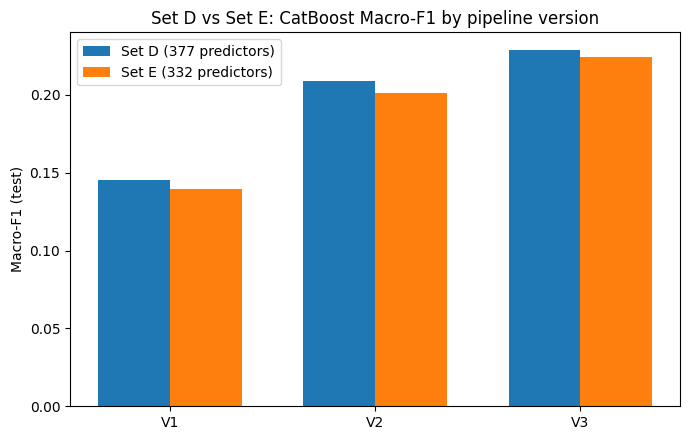

In [ ]:
import os

VERSION_LABELS = ["V1", "V2", "V3"]

# --- Set E: pull CatBoost's F1 Test for each version from this run's own results ---
sete_per_model = results["per_model_results"]
sete_catboost = (
    sete_per_model[sete_per_model["Model"] == "CatBoost"]
    .set_index("Version")["F1 Test"]
    .reindex(VERSION_LABELS)
)
if sete_catboost.isnull().any():
    missing = list(sete_catboost[sete_catboost.isnull()].index)
    raise RuntimeError(
        f"Set E per-model results are missing a CatBoost row for version(s): {missing}. "
        f"Re-run V1-V3 above before building the comparison."
    )

# --- Set D: load CatBoost's F1 Test for each version from the saved Set D results file ---
if not os.path.exists(SET_D_RESULTS_PATH):
    raise FileNotFoundError(
        f"Cannot build the Set D vs Set E comparison: '{SET_D_RESULTS_PATH}' was not found.\n"
        f"This file is produced by the Set D CatBoost supplementary experiment "
        f"(HSLS_catboost_experiment_v1.ipynb, EXPERIMENT_TAG='{SET_D_EXPERIMENT_TAG}'). "
        f"Run that notebook first (it saves its per-model V1-V3 results under this exact "
        f"filename), or place a copy of that CSV in this notebook's working directory, "
        f"then re-run this cell. No Set D values are hard-coded here."
    )

setd_per_model = pd.read_csv(SET_D_RESULTS_PATH)
setd_catboost = (
    setd_per_model[setd_per_model["Model"] == "CatBoost"]
    .set_index("Version")["F1 Test"]
    .reindex(VERSION_LABELS)
)
if setd_catboost.isnull().any():
    missing = list(setd_catboost[setd_catboost.isnull()].index)
    raise RuntimeError(
        f"'{SET_D_RESULTS_PATH}' is missing a CatBoost row for version(s): {missing}. "
        f"Check that the Set D CatBoost experiment ran and saved V1-V3 correctly."
    )

# --- Build the comparison DataFrame entirely from the two Series above ---
comparison = pd.DataFrame({
    "Version": VERSION_LABELS,
    "Set D CatBoost F1": setd_catboost.values,
    "Set E CatBoost F1": sete_catboost.values,
})
comparison["Difference (Set E - Set D)"] = (
    comparison["Set E CatBoost F1"] - comparison["Set D CatBoost F1"]
).round(4)

print(comparison.to_string(index=False))

comparison_path = f"{EXPERIMENT_TAG}_setD_vs_setE_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"\nSaved: {comparison_path}")

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["Set D CatBoost F1"], width, label="Set D (377 predictors)")
ax.bar(x + width/2, comparison["Set E CatBoost F1"], width, label="Set E (332 predictors)")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Version"])
ax.set_ylabel("Macro-F1 (test)")
ax.set_title("Set D vs Set E: CatBoost Macro-F1 by pipeline version")
ax.legend()
plt.tight_layout()
plt.savefig("fig_setD_setE_sensitivity.png", dpi=200)
plt.show()


### Programmatic summary (computed from `comparison`, not hard-coded)

In [ ]:
n_versions = len(comparison)
n_setE_lower_or_equal = int((comparison["Difference (Set E - Set D)"] <= 0).sum())
mean_diff = comparison["Difference (Set E - Set D)"].mean()
best_gain = comparison["Difference (Set E - Set D)"].max()

print(f"Versions where Set E CatBoost F1 <= Set D CatBoost F1: {n_setE_lower_or_equal} of {n_versions}")
print(f"Mean difference (Set E - Set D) across versions: {mean_diff:.4f}")
print(f"Largest single-version gain for Set E over Set D, any version: {best_gain:.4f}")
print(f"Set E predictor count (this run): {prep['n_features']}")


Versions where Set E CatBoost F1 <= Set D CatBoost F1: 3 of 3
Mean difference (Set E - Set D) across versions: -0.0060
Largest single-version gain for Set E over Set D, any version: -0.0045


NameError: name 'prep' is not defined

## Results Summary / Key Finding

- Set E reduces the predictor set relative to Set D by removing documented composite-
  scale redundancy, on the same set of records (see the printed data-loading output
  above for exact counts).
- Set E's complete-case V1 subsample size was unchanged from Set D -- the predictor
  reduction did not affect which records have complete data on the retained columns.
- Across V1, V2, and V3, Set E's CatBoost Macro-F1 did not exceed Set D's at any
  version tested (see the "Programmatic summary" cell above for the exact
  version-by-version figures and mean difference).
- Set E therefore reduced predictor count without improving held-out Macro-F1.
- **The sensitivity analysis therefore does not support replacing Set D with Set E for
  the main model.**